# Spectrogram Feature Extraction Demonstration
This outlines how a audio .wav file is converted into a Spectogram, and how the chord can be detected using a CNN.
This example will be done on a C chord.

In [4]:
# Imports
import librosa
import pandas as pd
import numpy as np
%matplotlib inline

## Loading File and Extracting Features
The *librosa* library is used to preform low-level feature extraction such as chromagrams, Mel spectrogram, MFCC, etc.

The audio file is loaded and decoded as a *time series* `y`, represented as a one-dimensional NumPy floating point array. The variable `sr` contains the sampling rate of `y`, that is, the number of samples per second of audio.
By default, all audio is mixed to mono and resampled to 22050 Hz at load time. 

In [3]:
# Load C major chord audio file
y, sr = librosa.load('chords-test/C_acoustic_guitar_fender_fa_series_1.wav')

# Compute mel-spectrogram features
spec = librosa.feature.melspectrogram(y=y, sr=sr)

# Show first 5 time steps
# print(spec[:, :5])

# Average mel-spectrogram values across time to get a single vector per chord
spec_mean = spec.mean(axis=1)
print(f"Average mel-spectrogram vector: \n{spec_mean}")  # show average mel-spectrogram vector

Average mel-spectrogram vector: 
[1.1112891e-02 9.1268994e-02 1.1291652e-01 1.0170256e+01 1.7554979e+02
 3.2078350e+01 8.8824759e+00 5.3273869e+00 5.1422181e+00 5.5891333e+00
 1.8944261e+00 5.0958997e-01 4.4029710e-01 3.8982287e-01 1.0773328e+01
 2.6747479e+00 4.4605836e-02 9.0178114e-01 1.0629622e+01 5.3651047e+00
 1.3959908e+00 3.2416224e-01 8.7344307e-01 6.1976459e-02 3.3329439e-01
 2.5284034e-01 3.1857997e-02 3.0726941e-02 7.5718635e-03 1.0144659e+00
 8.8120848e-01 2.1111023e-01 6.5376937e-02 8.4316740e-03 1.6719643e-02
 2.3191292e-02 1.6987637e-01 1.3435755e+00 4.6004352e-01 1.6962230e-01
 2.8567794e-01 4.2774186e-02 5.5901498e-02 6.8938023e-01 2.7868521e-01
 3.5539266e-02 2.0602850e-02 1.6931494e-01 1.1438226e+00 1.2630856e-01
 4.1649997e-02 2.4188507e-02 3.2810479e-02 3.5837386e-02 9.3914561e-02
 2.5804904e-01 4.9296327e-02 2.7749052e-02 8.2996599e-03 3.7685842e-03
 5.0856653e-03 1.0408159e-02 1.1269467e-02 4.4728510e-02 3.6554441e-02
 2.4222959e-02 3.0001799e-02 1.9321404e-02 1

[Text(0.5, 1.0, 'Mel-frequency spectrogram')]

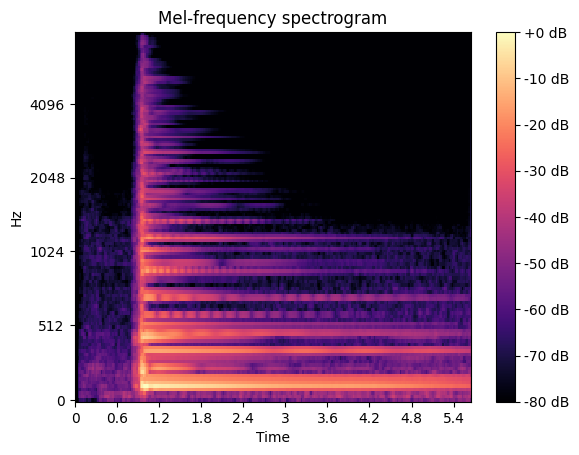

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
S_dB = librosa.power_to_db(spec, ref=np.max)
img = librosa.display.specshow(S_dB, x_axis='time',
                         y_axis='mel', sr=sr,
                         fmax=8000, ax=ax)
fig.colorbar(img, ax=ax, format='%+2.0f dB')
ax.set(title='Mel-frequency spectrogram')